# Notebook

### Step 1: Import Libraries

In [ ]:
"""
Data Cleaning and Analysis Notebook
"""
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings("ignore")

### Step 2: Load the dataset

In [2]:
df = pd.read_csv('dirty_sales.csv')
df.head(10)

,Product ID,Product Name,REGION,Units Sold,Unit Price,Total Sales,Profit Margin,Sale Date
0,1,AlphaWidget,North,10,$12.50,$125.00,10%,2020-01-03
1,2,betawidget,south,twenty,12.5,250.0,0.10,01/03/2020
2,3,Gamma Widget,EAST,"1,000","$1,234.56","$1,234,560",8 perscent,3 Jan 2020
3,4,NaN,west,5,"€10,00","50,00€",ten percent,20200104
4,5,DeltaWidget,North,NaN,15,NaN,5.5%,Mar 5 2019
5,6,epsilon,South,7,$0,0,0%,2019-12-31
6,7,Zeta,east,twenty five,$25.00,625,0.25,2019/12/30
7,8,Eta,West,3,"12,50","37,50",8%,12-31-2019
8,9,Theta,NORTH,2,$5,$10,0.1,2019.12.29
9,10,Iota,south,8,$9.99,79.92,8 persent,NaN


### Step 3: Check for missing values andinfo

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0    Product ID    100 non-null    int64
 1   Product Name   90 non-null     str  
 2    REGION        100 non-null    str  
 3   Units Sold     90 non-null     str  
 4    Unit Price    100 non-null    str  
 5   Total Sales    90 non-null     str  
 6   Profit Margin  100 non-null    str  
 7   Sale Date      90 non-null     str  
dtypes: int64(1), str(7)
memory usage: 6.4 KB


### Step 3.1: Handle missing values (NaN)

In [4]:
df.isnull().sum()

 Product ID       0
Product Name     10
 REGION           0
Units Sold       10
 Unit Price       0
Total Sales      10
Profit Margin     0
Sale Date        10
dtype: int64

#### Step 3.1.1: Ensure numeric columns are numeric before filling NaN

In [5]:
df["Units Sold"] = pd.to_numeric(df["Units Sold"], errors='coerce')
df["Total Sales"] = pd.to_numeric(df["Total Sales"], errors='coerce')
df.head(10) # Print first 10 rows to check the changes

,Product ID,Product Name,REGION,Units Sold,Unit Price,Total Sales,Profit Margin,Sale Date
0,1,AlphaWidget,North,10.0,$12.50,NaN,10%,2020-01-03
1,2,betawidget,south,NaN,12.5,250.00,0.10,01/03/2020
2,3,Gamma Widget,EAST,NaN,"$1,234.56",NaN,8 perscent,3 Jan 2020
3,4,NaN,west,5.0,"€10,00",NaN,ten percent,20200104
4,5,DeltaWidget,North,NaN,15,NaN,5.5%,Mar 5 2019
5,6,epsilon,South,7.0,$0,0.00,0%,2019-12-31
6,7,Zeta,east,NaN,$25.00,625.00,0.25,2019/12/30
7,8,Eta,West,3.0,"12,50",NaN,8%,12-31-2019
8,9,Theta,NORTH,2.0,$5,NaN,0.1,2019.12.29
9,10,Iota,south,8.0,$9.99,79.92,8 persent,NaN


#### Step 3.1.2: Fill missing numeric values with the column mean

In [6]:
df["Units Sold"] = df["Units Sold"].fillna(df["Units Sold"].mean())
df["Total Sales"] = df["Total Sales"].fillna(df["Total Sales"].mean())
df.head(10) # Check again after filling missing values

,Product ID,Product Name,REGION,Units Sold,Unit Price,Total Sales,Profit Margin,Sale Date
0,1,AlphaWidget,North,10.000000,$12.50,238.73,10%,2020-01-03
1,2,betawidget,south,5.833333,12.5,250.00,0.10,01/03/2020
2,3,Gamma Widget,EAST,5.833333,"$1,234.56",238.73,8 perscent,3 Jan 2020
3,4,NaN,west,5.000000,"€10,00",238.73,ten percent,20200104
4,5,DeltaWidget,North,5.833333,15,238.73,5.5%,Mar 5 2019
5,6,epsilon,South,7.000000,$0,0.00,0%,2019-12-31
6,7,Zeta,east,5.833333,$25.00,625.00,0.25,2019/12/30
7,8,Eta,West,3.000000,"12,50",238.73,8%,12-31-2019
8,9,Theta,NORTH,2.000000,$5,238.73,0.1,2019.12.29
9,10,Iota,south,8.000000,$9.99,79.92,8 persent,NaN


### Step 4: Clean column names (remove leading/trailing/spaces)
>> This step should be placed earlier, right after loading the dataset, to ensure all subsequent operations work with clean column names.

In [7]:
print(df.columns.tolist())
df.columns = df.columns.str.strip()
# Show only the column names to verify they are clean
print(df.columns.tolist())

[' Product ID ', 'Product Name', ' REGION', 'Units Sold', ' Unit Price ', 'Total Sales', 'Profit Margin', 'Sale Date']
['Product ID', 'Product Name', 'REGION', 'Units Sold', 'Unit Price', 'Total Sales', 'Profit Margin', 'Sale Date']


### Step 5: Fix date formats (turn inconsistent text into real date format: ISO 8601:2019)
! This step needs modification: The current code uses `pd.to_datetime()` which is the correct pandas function for converting strings to datetime objects.
The Problem is that if the date is in another format than ISO 8601, it will be removed and turned into NaT (Not a Time). To handle this, we can specify the `format` parameter in `pd.to_datetime()` to match the expected date format in the dataset. For example, if the dates are in the format "MM/DD/YYYY", we can use `format='%m/%d/%Y'`. This way, we can ensure that the dates are correctly parsed and converted to datetime objects without losing any information.

In [8]:
# Show the "Sale Date" column to check for any issues before conversion
print(df["Sale Date"].head(10))
df["Sale Date"] = pd.to_datetime(df["Sale Date"], errors='coerce')
# Show the "Sale Date" column again to verify the conversion with pandas syntax
print(df["Sale Date"].head(10))

0    2020-01-03
1    01/03/2020
2    3 Jan 2020
3      20200104
4    Mar 5 2019
5    2019-12-31
6    2019/12/30
7    12-31-2019
8    2019.12.29
9           NaN
Name: Sale Date, dtype: str
0   2020-01-03
1          NaT
2          NaT
3          NaT
4          NaT
5   2019-12-31
6          NaT
7          NaT
8          NaT
9          NaT
Name: Sale Date, dtype: datetime64[us]


### Step 6: Standardize text columns (make names consistent and neat)

In [9]:
# Print the column names to verify they are clean and consistent
print(df.columns.tolist())

for col in ["REGION", "Product Name"]:
    df[col] = df[col].str.strip().str.title()
    print(f"Unique values in '{col}' after cleaning:")
    print(df[col].unique())
# Show the cleaned categorical columns to verify the changes
print(df.columns.tolist())

['Product ID', 'Product Name', 'REGION', 'Units Sold', 'Unit Price', 'Total Sales', 'Profit Margin', 'Sale Date']
Unique values in 'REGION' after cleaning:
<StringArray>
['North', 'South', 'East', 'West']
Length: 4, dtype: str
Unique values in 'Product Name' after cleaning:
<StringArray>
[ 'Alphawidget',   'Betawidget', 'Gamma Widget',            nan,
  'Deltawidget',      'Epsilon',         'Zeta',          'Eta',
        'Theta',         'Iota']
Length: 10, dtype: str
['Product ID', 'Product Name', 'REGION', 'Units Sold', 'Unit Price', 'Total Sales', 'Profit Margin', 'Sale Date']


### Step 7: Convert Units Sold to numeric (turn words like "twenty" into NaN)

In [10]:
df["Units Sold"] = pd.to_numeric(df["Units Sold"], errors='coerce')
df["Total Sales"] = pd.to_numeric(df["Total Sales"], errors='coerce')

### Step 8: Clean currency columsn (Unit Price, Todal Sales)

In [11]:
for col in ["Units Sold", "Total Sales"]:
    df[col] = df[col].astype(str)
    df[col] = (
        df[col]
        .str.replace("[$,USD]", "", regex=True)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

### Step 9: Fix Profit Margin (%)
- Some values are like '10%', '0.10', or '8 perscent' - let's make them consistent

In [12]:
df["Profit Margin"] = (
    df["Profit Margin"]
    .astype(str)
    .str.replace("%", "", regex=True)
    .str.replace("percent", "", regex=True)
    .str.replace("ten ", "", regex=True)
    .str.replace("perscent", "", regex=True)
    .str.strip()
)
df["Profit Margin"] = pd.to_numeric(df["Profit Margin"], errors='coerce')

df["Profit Margin (%)"] = np.where(
    df["Profit Margin"] < 1, df["Profit Margin"] * 100, df["Profit Margin"]
)

### Step 10: Drop rows with missing key data (clean final dataset)

In [13]:
df_cleaned = df.dropna(subset=["REGION", "Product Name", "Sale Date"])

### Step 11: Check cleaned results

In [14]:
df_cleaned.head(10)

,Product ID,Product Name,REGION,Units Sold,Unit Price,Total Sales,Profit Margin,Sale Date,Profit Margin (%)
0,1,Alphawidget,North,10.0,$12.50,238.73,10.0,2020-01-03,10.0
5,6,Epsilon,South,7.0,$0,0.00,0.0,2019-12-31,0.0
10,11,Alphawidget,North,10.0,$12.50,238.73,10.0,2020-01-03,10.0
15,16,Epsilon,South,7.0,$0,0.00,0.0,2019-12-31,0.0
20,21,Alphawidget,North,10.0,$12.50,238.73,10.0,2020-01-03,10.0
25,26,Epsilon,South,7.0,$0,0.00,0.0,2019-12-31,0.0
30,31,Alphawidget,North,10.0,$12.50,238.73,10.0,2020-01-03,10.0
35,36,Epsilon,South,7.0,$0,0.00,0.0,2019-12-31,0.0
40,41,Alphawidget,North,10.0,$12.50,238.73,10.0,2020-01-03,10.0
45,46,Epsilon,South,7.0,$0,0.00,0.0,2019-12-31,0.0


### Step 12: Total Sales by Region

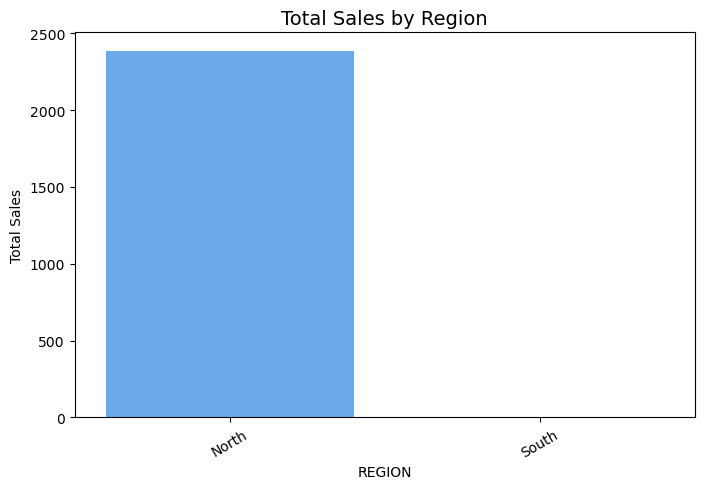

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_cleaned, x="REGION", y="Total Sales", estimator=sum, palette="cool")
plt.title("Total Sales by Region", fontsize=14)
plt.xticks(rotation=30)
plt.show()

### Step 13: Sales Trend Over Time

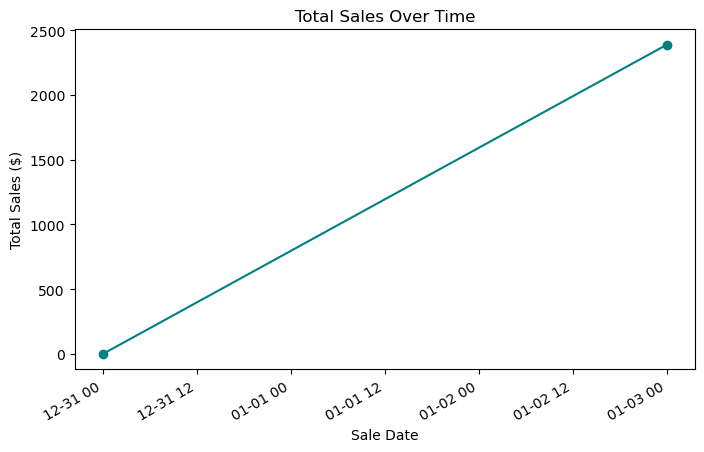

In [16]:
plt.figure(figsize=(8, 5))
df_cleaned.groupby("Sale Date")["Total Sales"].sum().plot(kind="line", marker="o", color="teal")
plt.title("Total Sales Over Time")
plt.ylabel("Total Sales ($)")
plt.show()

### Step 14: Category Share Pie Chart

Text(0, 0.5, '')

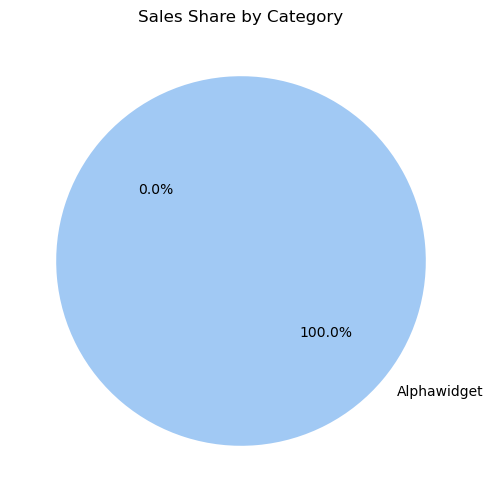

In [17]:
plt.figure(figsize=(6, 6))
category_sales =(
    df_cleaned
    .groupby("Product Name")["Total Sales"]
    .sum()
    .sort_values(ascending=False)
    )
category_sales.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("pastel")
    )
plt.title("Sales Share by Category")
plt.ylabel("")